<a href="https://colab.research.google.com/github/manfredialdo/iad-tpi01/blob/main/tpi01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏨 Clase de Consulta: Estadística Descriptiva Aplicada al Dataset del TPI
**Cátedra:** Introducción al Análisis de Datos — UTN TUPAD

**Objetivo:** Explorar las métricas de tendencia central, dispersión y frecuencias utilizando el dataset real de reservas hoteleras.

**Fecha:** 13/08/2026

### 📌 Buenas Prácticas en Notebooks:
 1. **Ejecución Cronológica:** Ejecuta las celdas de arriba hacia abajo para mantener la memoria limpia.
2. **Modularización:** Una función/propósito por celda.
 3. **Narrativa + Código:** El código calcula, el texto interpreta.

is_canceled Binaria / objetivo Indica si la reserva fue cancelada. 0 = no

cancelada, 1 = cancelada.




In [2]:
# 1. Importación de librerías esenciales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual limpia para los gráficos
sns.set_theme(style="whitegrid")
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


##  1 - Carga del Dataset y Reconocimiento General
Antes de calcular cualquier promedio o porcentaje, la regla de oro del analista es entender la estructura básica del dataset:
* ¿Cuántos registros (filas) y variables (columnas) tenemos?
* ¿Qué tipo de variable es cada una según nuestro **Diccionario de Variables**?

In [39]:
# Carga del archivo CSV
url = "https://raw.githubusercontent.com/manfredialdo/iad-tpi01/refs/heads/main/hotel%20booking%20TPI%20grupo%20J.csv"
df = pd.read_csv(url)

# Mostrar dimensiones
filas, columnas = df.shape
print(f"El dataset contiene {filas} reservas y {columnas} variables.")

# Visualizar las primeras 5 filas
df.head(5)
#df.info()
df['is_canceled'].describe()

El dataset contiene 25000 reservas y 32 variables.


,is_canceled
count,25000.000000
mean,0.370360
std,0.482911
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [17]:
# Comprobar la cantidad de filas canceladas (1) y no canceladas (0)
print("Frecuencia absoluta:")
print(df["is_canceled"].value_counts())

# Tasa porcentual de cancelación
print("\nTasa de cancelación (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

Frecuencia absoluta:
is_canceled
0    15741
1     9259
Name: count, dtype: int64

Tasa de cancelación (%):
is_canceled
0    62.964
1    37.036
Name: proportion, dtype: float64


In [19]:
df.columns

Index(['booking_id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'arrival_date', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

In [ ]:
dir(df['is_canceled'])

In [ ]:
# dir(df['is_canceled'].mean())

In [23]:
df['is_canceled'].mean()

np.float64(0.37036)

In [24]:
df['is_canceled'].sum()

np.int64(9259)

In [29]:
# Resumen completo de la variable
s = df['is_canceled']
print(f"Tipo de dato: {s.dtype}")
print(f"Valores nulos: {s.isna().sum()}")
print(f"Valores únicos: {s.unique()}")
print(f"Tasa de cancelación (Media): {s.mean():.4f}")
print(f"total de la muestra: {s.count():.4f}")
print(f"cuantas cancelaciones hubo: {s.sum():.4f}")

Tipo de dato: int64
Valores nulos: 0
Valores únicos: [0 1]
Tasa de cancelación (Media): 0.3704
total de la muestra: 25000.0000
cuantas cancelaciones hubo: 9259.0000


In [31]:
# Resumen completo de la variable is_canceled
s = df['is_canceled']

print(f"Tipo de dato: {s.dtype}")
print(f"Valores nulos: {s.isna().sum()}")
print(f"Valores únicos: {s.unique()}")
print(f"Total de la muestra: {s.count():,}")
print(f"Cuántas cancelaciones hubo: {s.sum():,}")
print(f"Tasa de cancelación (Media): {s.mean():.4f} ({s.mean()*100:.2f}%)")
print(f"Moda (Valor más frecuente): {s.mode()[0]}")

Tipo de dato: int64
Valores nulos: 0
Valores únicos: [0 1]
Total de la muestra: 25,000
Cuántas cancelaciones hubo: 9,259
Tasa de cancelación (Media): 0.3704 (37.04%)
Moda (Valor más frecuente): 0


## 2 -  Variables Categóricas: Fr. Absolutas y Relativas
Las frecuencias organizan variables cualitativas o binarias.
Veamos qué pasa con **`is_canceled`**

($0 =$ Reserva Efectiva, $1 =$ Reserva Cancelada):
* **Frecuencia Absoluta:** Conteo puro de reservas.
* **Frecuencia Relativa:** Porcentaje respecto al total (evita engaños por volumen).

                  Cantidad de Reservas  Porcentaje (%)
No Cancelada (0)                 15741           62.96
Cancelada (1)                     9259           37.04


/tmp/ipykernel_824/633795712.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_canceled', palette=['#2ec4b6', '#e71d36'])


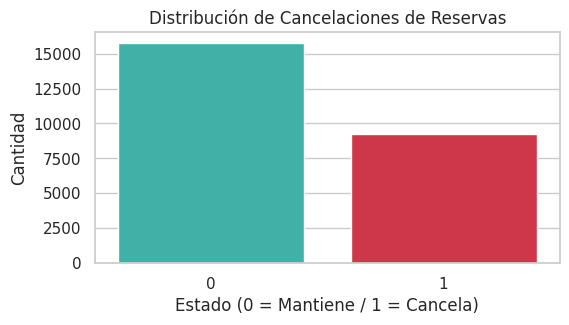

<Axes: xlabel='is_canceled', ylabel='count'>

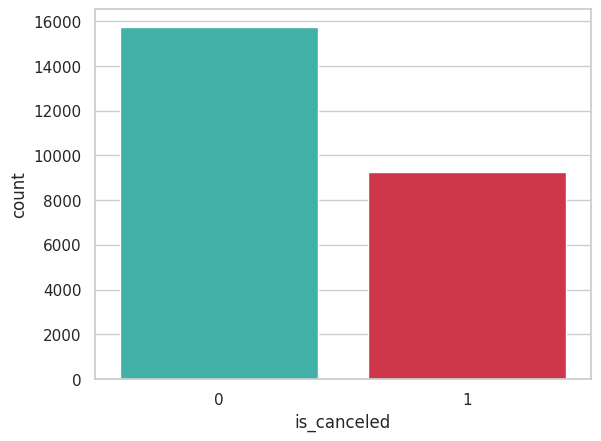

In [6]:
# Cálculo de frecuencias para cancelaciones
frec_absoluta = df['is_canceled'].value_counts()
frec_relativa = df['is_canceled'].value_counts(normalize=True) * 100

# Crear una tabla resumen
tabla_cancelaciones = pd.DataFrame({
    'Cantidad de Reservas': frec_absoluta,
    'Porcentaje (%)': frec_relativa.round(2)
})
tabla_cancelaciones.index = ['No Cancelada (0)', 'Cancelada (1)']
print(tabla_cancelaciones)

# Gráfico de Barras Simple
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='is_canceled', palette=['#2ec4b6', '#e71d36'])
plt.title('Distribución de Cancelaciones de Reservas')
plt.xlabel('Estado (0 = Mantiene / 1 = Cancela)')
plt.ylabel('Cantidad')
plt.show()



sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette=['#2ec4b6', '#e71d36'], legend=False)

💡 Vemos que más de 1/3 de los clientes cancelan su reserva... casi la mitad en realidad, un 37% cancela... se deberia prestar atencion al problema??

Magnitud del impacto operacional: Prácticamente 4 de cada 10 reservas (37.04%) se cancelan, lo que representa una pérdida masiva de ingresos potenciales e incertidumbre operacional para el hotel.



Volumen de conversión real: El hotel solo logra concretar efectivamente el 62.96% de las intenciones de reserva recibidas (15,741 noches/estancias efectivas).



Distribución del desbalance de clases: Para fines de modelado estadístico o Machine Learning, la variable objetivo (is_canceled) presenta un desbalance moderado (proporción aproximada de 63:37), por lo que no requiere técnicas extremas de rebalanceo (como SMOTE), pero sí evaluar métricas más allá del accuracy.



Capacidad de Overbooking / Sobreventa: El dato de 37.04% de cancelación le da al hotel una métrica cuantitativa directa para definir políticas de sobreventa (overbooking) orientadas a compensar la habitación que probablemente quedará vacía.



Línea de base (Baseline) para segmentación: Funciona como el punto de comparación general. Cualquier subgrupo (por país, canal de venta o tipo de cliente) que tenga una tasa de cancelación significativamente superior o inferior al 37.04% se considerará de alto o bajo riesgo respecto a la media.

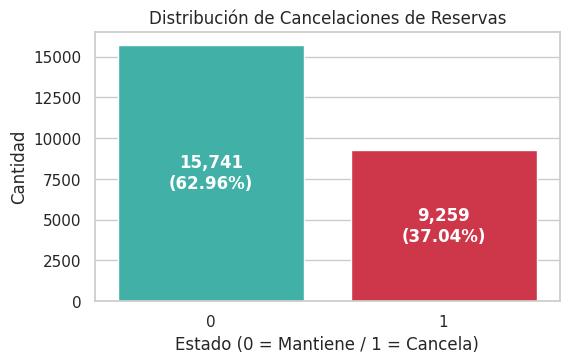

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3.5))
ax = sns.countplot(
    data=df,
    x='is_canceled',
    hue='is_canceled',
    palette=['#2ec4b6', '#e71d36'],
    legend=False
)

# Calcular total para sacar porcentajes
total = len(df)

# Agregar las etiquetas con cantidad y porcentaje sobre cada barra
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.2f}%'
    ax.annotate(f'{int(height):,}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.title('Distribución de Cancelaciones de Reservas')
plt.xlabel('Estado (0 = Mantiene / 1 = Cancela)')
plt.ylabel('Cantidad')
plt.show()

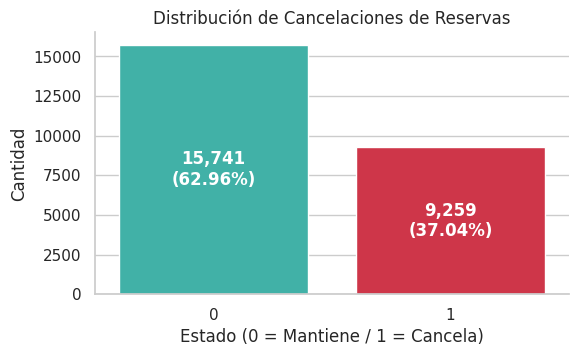

In [9]:
g = sns.catplot(
    data=df,
    x='is_canceled',
    kind='count',
    hue='is_canceled',
    palette=['#2ec4b6', '#e71d36'],
    legend=False,
    height=3.5,
    aspect=1.7
)

ax = g.ax
total = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.2f}%'
        ax.annotate(f'{int(height):,}\n({percentage})',
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.title('Distribución de Cancelaciones de Reservas')
plt.xlabel('Estado (0 = Mantiene / 1 = Cancela)')
plt.ylabel('Cantidad')
plt.show()

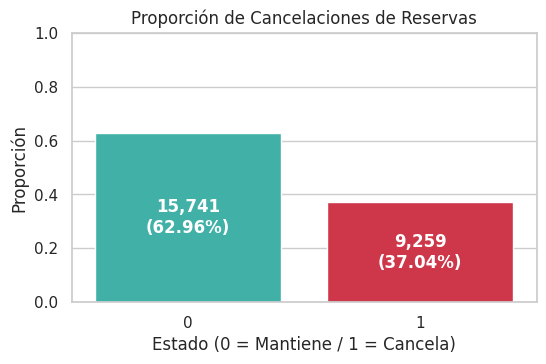

In [10]:
plt.figure(figsize=(6, 3.5))
# Dibujamos las barras escaladas a proporciones (0 a 1)
ax = sns.barplot(
    x=df['is_canceled'].value_counts(normalize=True).index,
    y=df['is_canceled'].value_counts(normalize=True).values,
    hue=df['is_canceled'].value_counts(normalize=True).index,
    palette=['#2ec4b6', '#e71d36'],
    legend=False
)

counts = df['is_canceled'].value_counts()
total = len(df)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    count_val = counts.iloc[i]
    percentage = f'{100 * height:.2f}%'
    ax.annotate(f'{count_val:,}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.title('Proporción de Cancelaciones de Reservas')
plt.xlabel('Estado (0 = Mantiene / 1 = Cancela)')
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.show()

## 3 - Medidas de Tendencia Central: Media, Mediana y Moda
Evaluaremos la variable **`lead_time`** (días transcurridos entre la fecha de reserva y la llegada al hotel).

* **Media (Promedio):** Sensible a valores extremos (outliers).
* **Mediana (Percentil 50):** El valor central que divide al 50% de los datos; robusta frente a atípicos.
* **Moda:** El valor que más veces se repite.

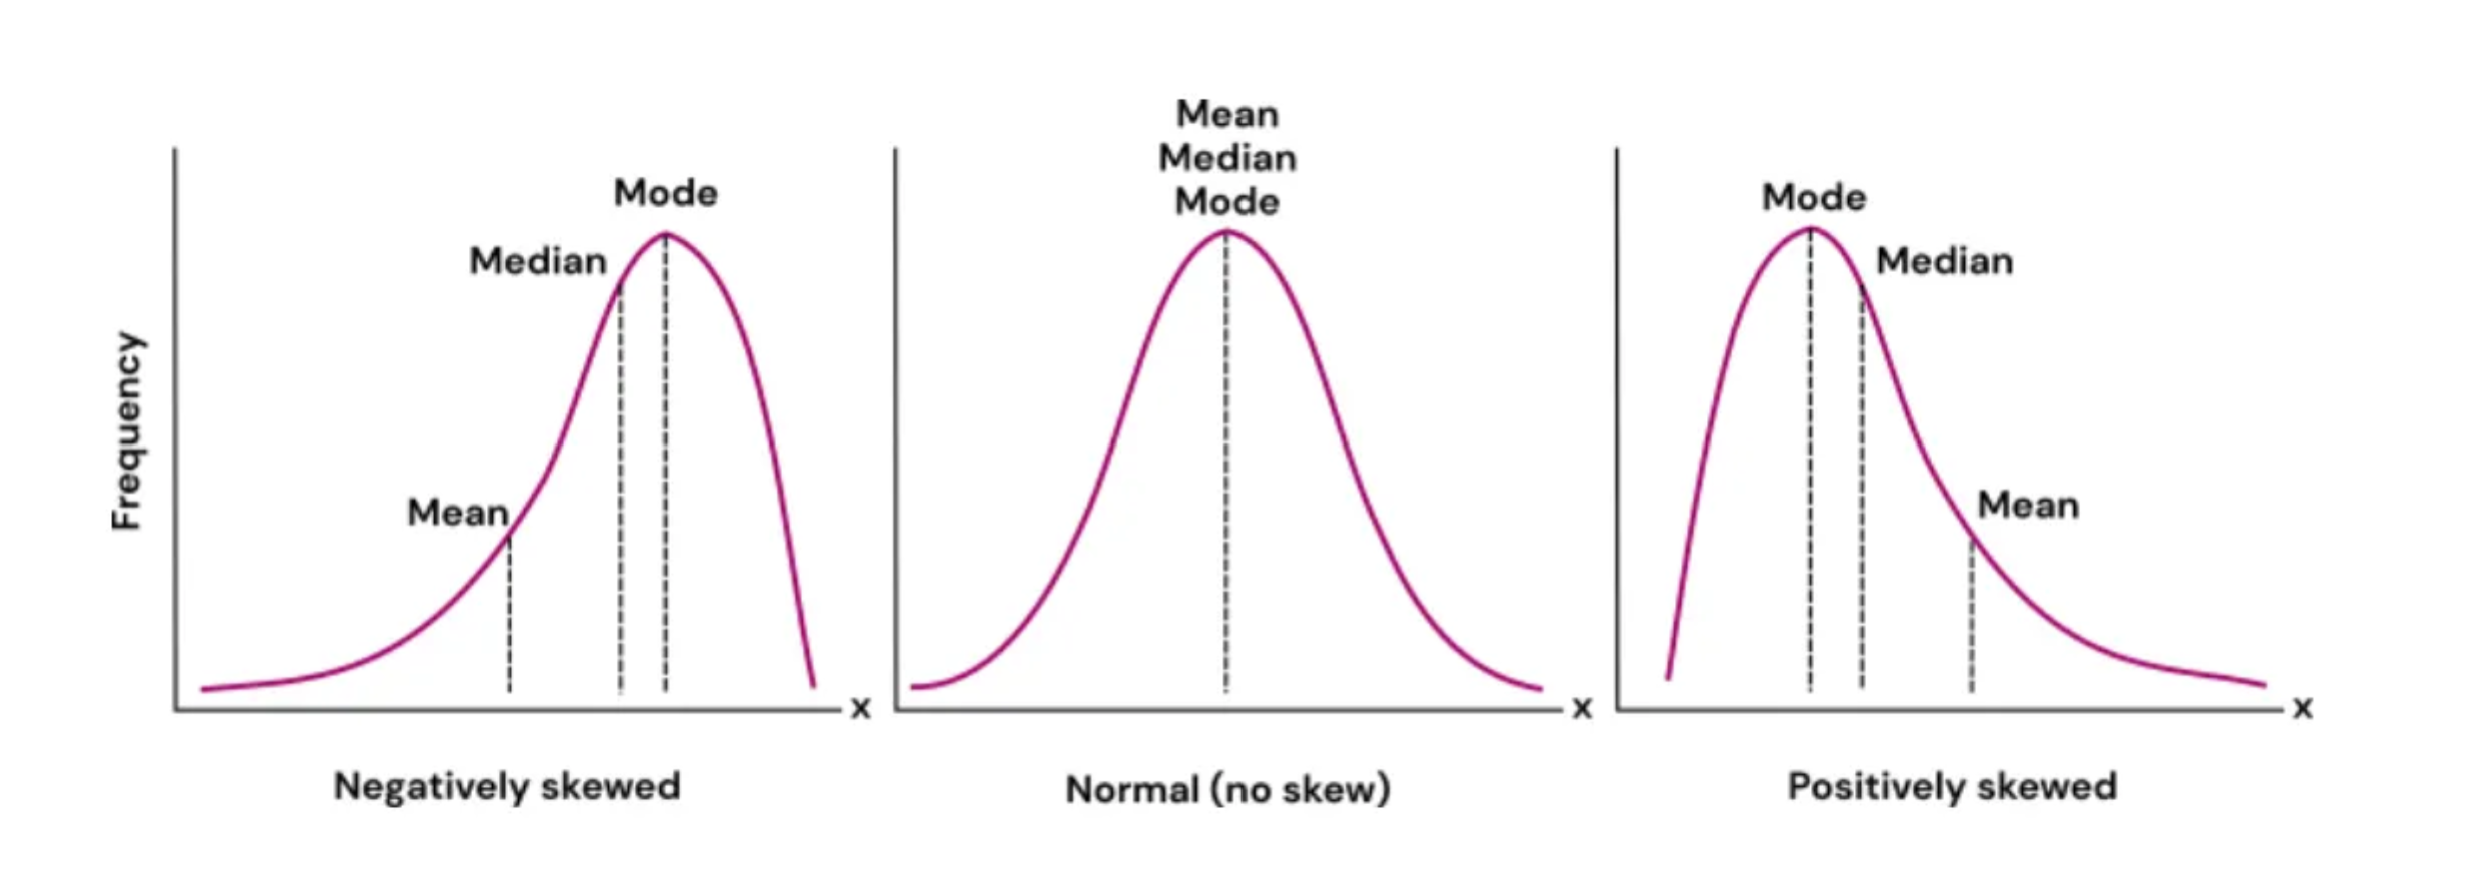

📌 Media (Promedio): 104.2 días
📌 Mediana (P50):    69.0 días
📌 Moda (Más común): 0 días


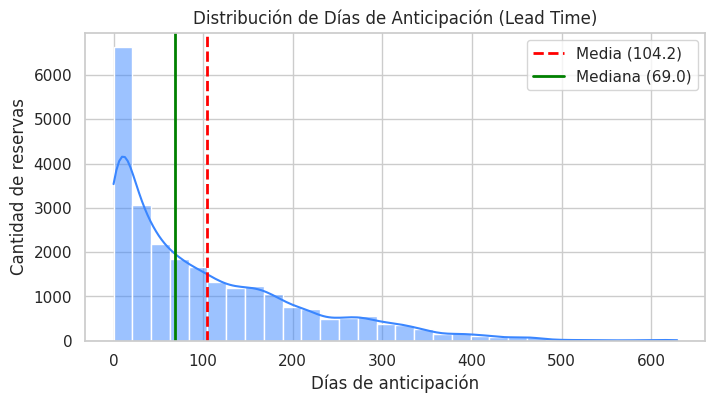

In [12]:
# Cálculos estadísticos para 'lead_time'
media_lead = df['lead_time'].mean()
mediana_lead = df['lead_time'].median()
moda_lead = df['lead_time'].mode()[0]

print(f"📌 Media (Promedio): {media_lead:.1f} días")
print(f"📌 Mediana (P50):    {mediana_lead:.1f} días")
print(f"📌 Moda (Más común): {moda_lead} días")

# Histograma para ver la forma de la distribución (Asimetría)
plt.figure(figsize=(8, 4))
sns.histplot(df['lead_time'], bins=30, kde=True, color='#3a86ff')
plt.axvline(media_lead, color='red', linestyle='--', linewidth=2, label=f'Media ({media_lead:.1f})')
plt.axvline(mediana_lead, color='green', linestyle='-', linewidth=2, label=f'Mediana ({mediana_lead:.1f})')
plt.title('Distribución de Días de Anticipación (Lead Time)')
plt.xlabel('Días de anticipación')
plt.ylabel('Cantidad de reservas')
plt.legend()
plt.show()

💡 Vemos que la **media** (promedio) es mayor que la **mediana**. Esto indica una **asimetría a la derecha**: hay un grupo reducido de clientes que reserva con *muchísimos* días de anticipación (valores atípicos) que empujan el promedio hacia arriba. Para estimar el comportamiento "típico" del cliente, la **mediana** es una medida más representativa aquí.

## 4 - Medidas de Dispersión y Posición: Variabilidad y Boxplot
Para la tarifa diaria promedio (**`adr`** en USD), no alcanza con saber el promedio: necesitamos conocer la dispersión (cuán dispersos están los precios).

* **Rango:** Diferencia entre el Máximo y el Mínimo.
* **Desvío Estándar ($S$):** Promedio de alejamiento respecto a la media.
* **Cuartiles ($Q_1, Q_2, Q_3$):** Cortes en 25%, 50% y 75% de la población.

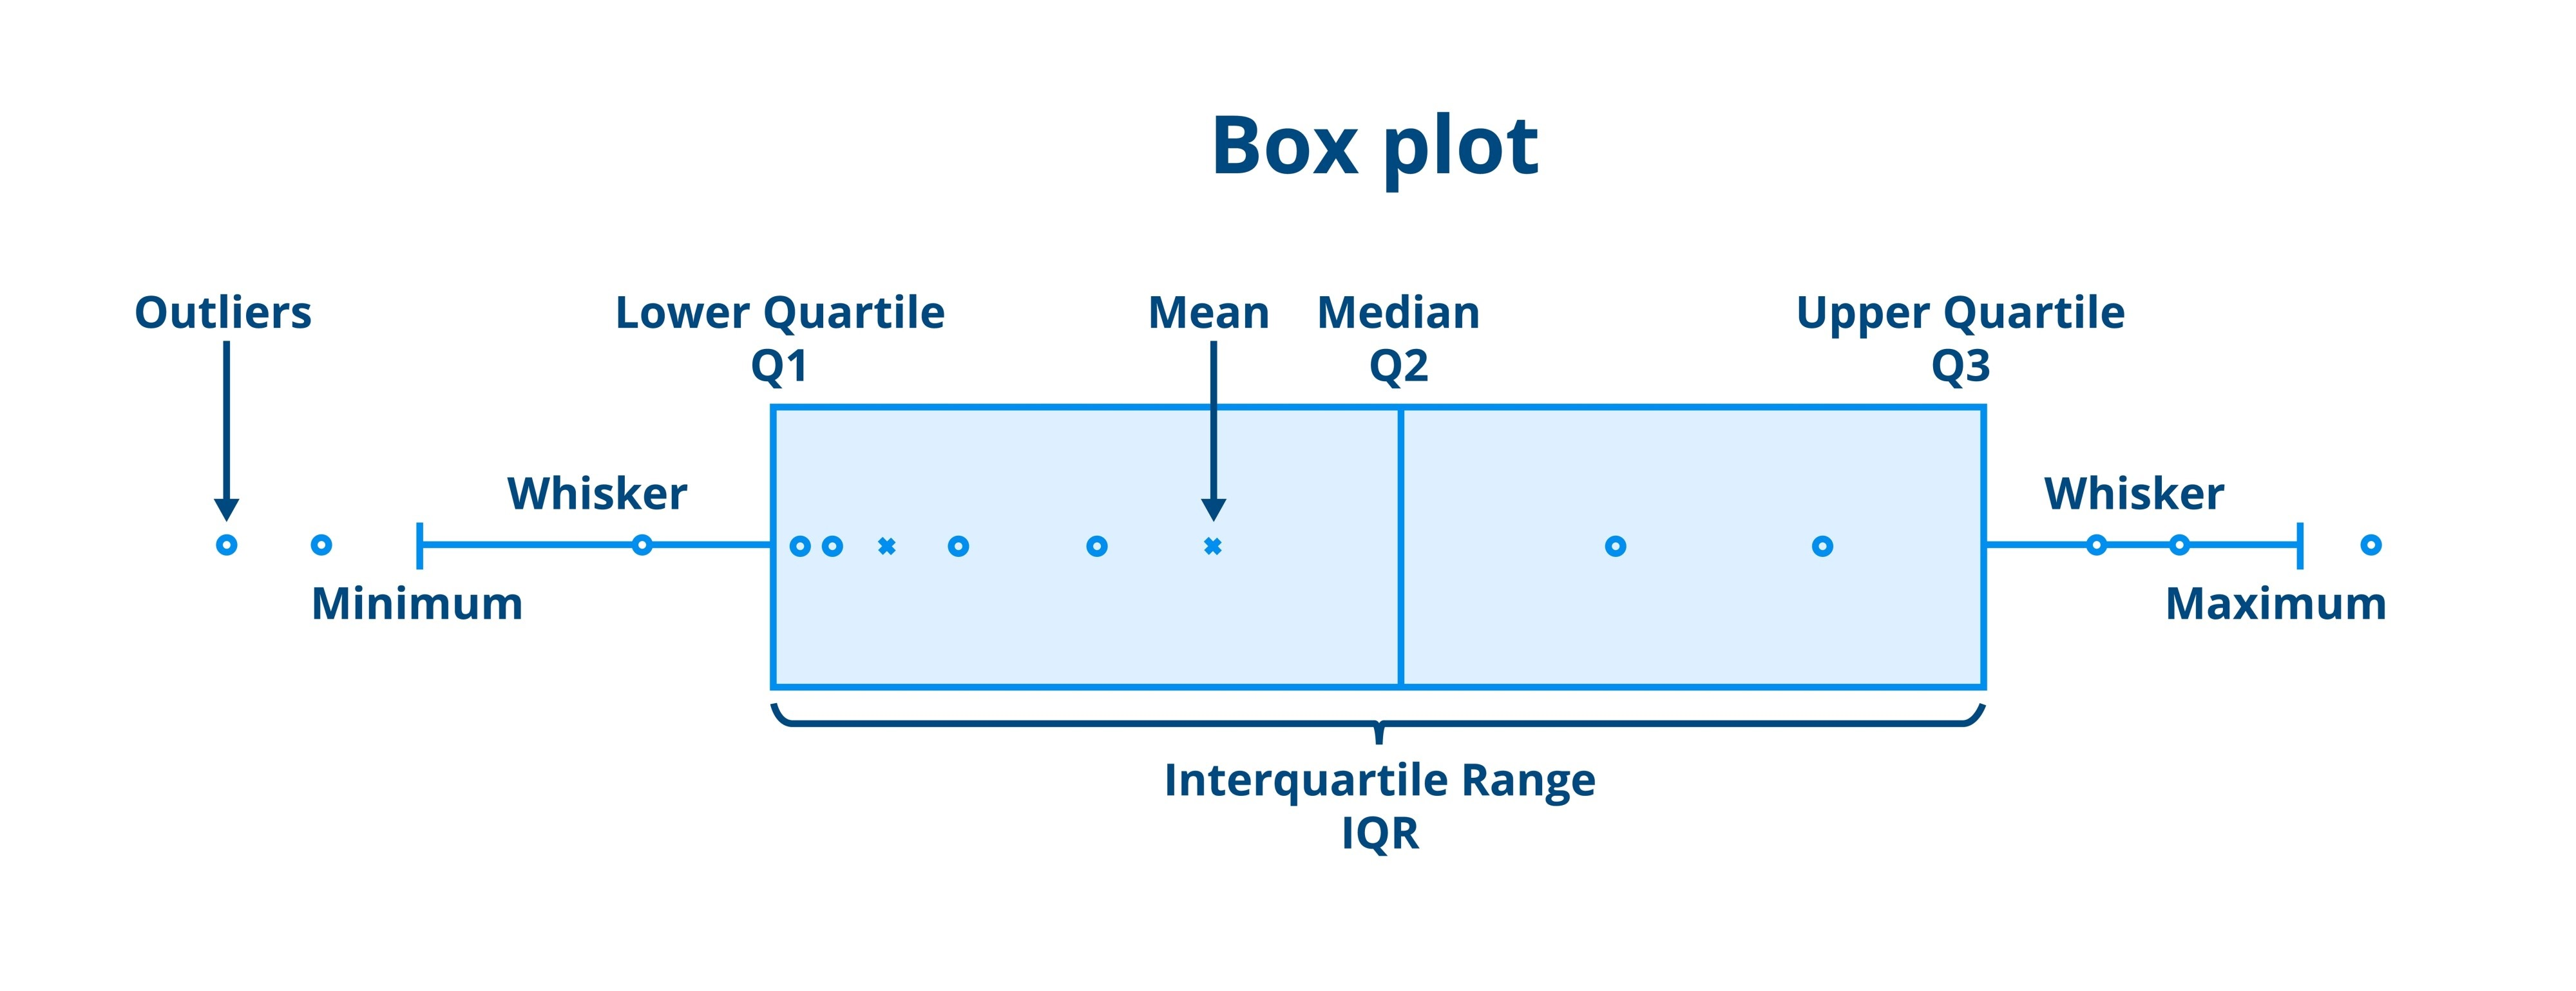

min      0.000000
25%     69.027500
50%     94.500000
75%    126.000000
max    387.000000
std     47.969113
Name: adr, dtype: float64


/tmp/ipykernel_824/618775880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='hotel', y='adr', palette='Set2')


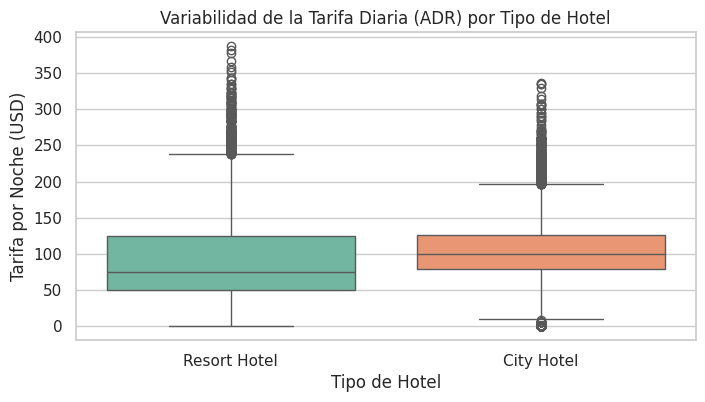

In [13]:
# Mínimo, Máximo, Desvío Estándar y Cuartiles en un solo paso
resumen_adr = df['adr'].describe()
print(resumen_adr[['min', '25%', '50%', '75%', 'max', 'std']])

# Gráfico de Boxplot (Diagrama de Caja) por Tipo de Hotel
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='hotel', y='adr', palette='Set2')
plt.title('Variabilidad de la Tarifa Diaria (ADR) por Tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Tarifa por Noche (USD)')
plt.show()

El 50% central de los clientes paga entre **69.03 USD y 126,00** USD por noche.

La mediana de **94,35 USD** representa mejor la tarifa habitual que el promedio, ya que la media se ve distorsionada por valores atípicos elevados de hasta 387 USD.

Finalmente, las tarifas mínimas de 0 USD advierten la presencia de cortesías, promociones o datos erróneos a auditar🚩

Punto central (Mediana = 94.50): El 50% de las reservas se vendió por debajo de $94.50 (o la moneda del dataset) y el otro 50% por encima, lo que marca el precio verdaderamente representativo del hotel.



Rango intercuartílico (69.03 - 126.00): El 50% "central" de todas las reservas oscila entre $69.03 y $126.00 por noche, definiendo la banda de precios habitual del negocio.



Presencia de valores atípicos (Max = 387.00): Existe al menos una reserva con una tarifa máxima muy elevada ($387.00), bastante alejada del límite del 75% ($126.00), lo que sugiere la presencia de outliers o habitaciones de categoría ejecutiva/suite.



Existencia de reservas gratuitas o promocionales (Min = 0.00): El valor mínimo registrado es $0.00, lo que indica reservas de cortesía, puntos de fidelidad, cortesías de personal o datos con algún tipo de registro especial.




Dispersión moderada (Std = 47.97): La desviación estándar indica una variabilidad considerable en los precios alrededor de la media, impulsada por la estacionalidad, los diferentes tipos de habitación o la dinámica de precios según el canal.

<Axes: xlabel='hotel', ylabel='adr'>

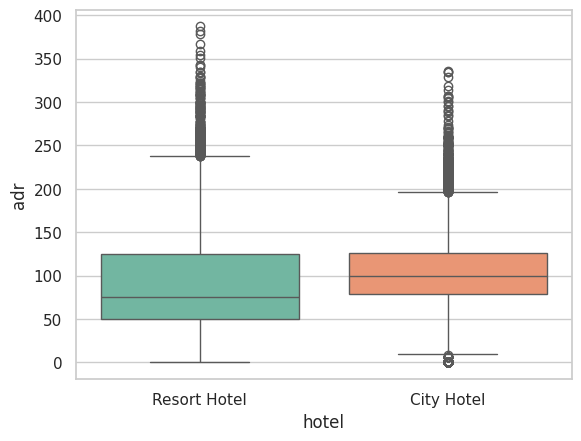

In [14]:
sns.boxplot(data=df, x='hotel', y='adr', hue='hotel', palette='Set2', legend=False)

## 5 - Síntesis y Cierre de la Sesión
1. **Ninguna medida vive sola:** Un promedio sin desvío estándar o sin comparar contra la mediana puede llevar a conclusiones erróneas.
2. **El tipo de variable manda:** Las categóricas se resumen con frecuencias; las cuantitativas con tendencia central y dispersión.
3. **Insights clave:** La proporción de reservas canceladas y los valores extremos en las tarifas son variables a estudiar.

Revela 5 puntos estratégicos sobre los datos:

Tasa de pérdida / Cancelación efectivizada: El 37.04% de las intenciones de reserva termina en cancelación, lo que representa una fuga directa de clientes potenciales antes de su llegada.

Tasa de ocupación o conversión inicial: Solo el 62.96% (15,741 reservas) se convierte en una estancia real concretada para el hotel.

Proporción de pérdidas (Relación 5 a 3): Por cada 5 reservas que se mantienen con éxito, aproximadamente 3 terminan siendo canceladas.

Equilibrio para modelos predictivos (Machine Learning): La relación de clases es ~63:37, lo que demuestra un desbalance moderado. Esto es positivo porque el modelo tiene suficientes ejemplos de ambas situaciones para aprender a predecir cancelaciones sin necesitar técnicas complejas de rebalanceo (como SMOTE).

Métrica de referencia (Baseline / Benchmark): Establece el valor promedio global contra el cual evaluarás cualquier otra variable. Si al segmentar por país, tipo de cliente o canal de venta ves tasas superiores al 37.04%, habrás identificado un segmento de alto riesgo.

In [32]:
# Resumen completo de la variable is_canceled
s = df['is_canceled']

print(f"Tipo de dato: {s.dtype}")
print(f"Valores nulos: {s.isna().sum()}")
print(f"Valores únicos: {s.unique()}")
print(f"Total de la muestra: {s.count():,}")
print(f"Cuántas cancelaciones hubo: {s.sum():,}")
print(f"Tasa de cancelación (Media): {s.mean():.4f} ({s.mean()*100:.2f}%)")
print(f"Moda (Valor más frecuente): {s.mode()[0]}")

Tipo de dato: int64
Valores nulos: 0
Valores únicos: [0 1]
Total de la muestra: 25,000
Cuántas cancelaciones hubo: 9,259
Tasa de cancelación (Media): 0.3704 (37.04%)
Moda (Valor más frecuente): 0


In [33]:
# Resumen exploratorio en formato de preguntas para la variable is_canceled
s = df['is_canceled']

print(f"1. ¿De qué tipo técnico es la columna? {s.dtype}")
print(f"2. ¿Cuántas reservas se analizaron en total? {s.count():,}")
print(f"3. ¿Existen datos faltantes o nulos en la columna? {s.isna().sum()}")
print(f"4. ¿Cuáles son las categorías o estados posibles? {s.unique()}")
print(f"5. ¿Cuántas cancelaciones se registraron en total? {s.sum():,}")
print(f"6. ¿Cuántas reservas NO se cancelaron (fueron efectivas)? {(s == 0).sum():,}")
print(f"7. ¿Cuál es la proporción exacta de cada estado? \n{s.value_counts(normalize=True)}")
print(f"8. ¿Cuál es el comportamiento típico o estado predominante? {s.mode()[0]}")
print(f"9. ¿Cuál es el porcentaje global de cancelación? {s.mean() * 100:.2f}%")
print(f"10. ¿Cuánta memoria RAM consume esta variable? {s.memory_usage(deep=True):,} bytes")

1. ¿De qué tipo técnico es la columna? int64
2. ¿Cuántas reservas se analizaron en total? 25,000
3. ¿Existen datos faltantes o nulos en la columna? 0
4. ¿Cuáles son las categorías o estados posibles? [0 1]
5. ¿Cuántas cancelaciones se registraron en total? 9,259
6. ¿Cuántas reservas NO se cancelaron (fueron efectivas)? 15,741
7. ¿Cuál es la proporción exacta de cada estado? 
is_canceled
0    0.62964
1    0.37036
Name: proportion, dtype: float64
8. ¿Cuál es el comportamiento típico o estado predominante? 0
9. ¿Cuál es el porcentaje global de cancelación? 37.04%
10. ¿Cuánta memoria RAM consume esta variable? 200,132 bytes


diagnostico



Elevado nivel de pérdida: La tasa de cancelación global del 37.04% (9,259 reservas) representa un riesgo alto de habitaciones vacías y pérdida de ingresos esperados.

Comportamiento base predominante: La moda es 0 (Mantiene). El estado natural o por defecto de una reserva en esta muestra es concretarse, representando casi 2 tercios del total (62.96% con 15,741 estancias efectivas).

Métrica de referencia para toma de decisiones: Este 37.04% define el punto de corte (baseline). Cualquier segmento o canal de venta con un porcentaje superior a esta cifra deberá ser marcado como de alto riesgo de cancelación.

In [40]:
df['is_canceled'].describe()

,is_canceled
count,25000.000000
mean,0.370360
std,0.482911
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Muestra completa (count: 25000): Confirma que los 25,000 registros de la muestra contienen datos válidos y no hay valores faltantes (NaN).


Tasa real en forma decimal (mean: 0.370360): En variables con valores de 0 y 1, la media aritmética equivale exactamente a la proporción de "1s". Indica que el 37.04% del dataset corresponde a cancelaciones.

Alta variabilidad (std: 0.482911): La desviación estándar está muy cercana al máximo teórico para una variable Bernoulli ($0.5$), reflejando una dispersión amplia entre los dos únicos estados.

Límites de rango (min: 0, max: 1): Revalida que los datos están perfectamente acotados entre 0 y 1, sin valores erróneos fuera del dominio binario.

Distribución de percentiles (25%: 0, 50%: 0, 75%: 1):

Percentil 25% y 50% (Mediana): Ambos valen 0.0. Más de la mitad de las reservas (el 62.96%) son no canceladas.

Percentil 75%: Pasa a 1.0. Indica el punto dentro del acumulado ordenado donde las cancelaciones entran en juego dentro de la distribución acumulada del 37.04% superior.